## FEATURE ENGINEERING AND FITTING

In [66]:
import numpy as np
import pandas as pd
import sklearn
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error ,r2_score
import joblib

In [67]:
#!ls -l china-real-estate-demand-prediction/train

In [68]:
def month_sect_conv(df: pd.DataFrame) -> pd.DataFrame:
    """
    This function takes a Pandas DataFrame, to divide month and year and convert sectors to integers dtype
    """
    if 'month' in df.columns:
        df["ts"] = pd.to_datetime(df['month'], format='%Y-%b')
        df["month"] = df["ts"].dt.month
        df["year"] = df["ts"].dt.year        
        df.drop('ts', axis=1, inplace=True)
        
    if 'sector' in df.columns:
        df['sector'] = df['sector'].str.replace('sector ', '')
        df['sector'] = df['sector'].astype(int)

    return df


def change_indx_to_zero(df: pd.DataFrame, col_name='time_index') -> pd.DataFrame:
    X2 = df.pop(col_name)
    df.insert(0, col_name, X2)

    return df

In [69]:
#Loading all the train data

city_indexes = pd.read_csv('china-real-estate-demand-prediction/train/city_indexes.csv')
city_search_index = pd.read_csv('china-real-estate-demand-prediction/train/city_search_index.csv')

land_transactions = pd.read_csv('china-real-estate-demand-prediction/train/land_transactions.csv')
land_transactions_nearby_sectors = pd.read_csv('china-real-estate-demand-prediction/train/land_transactions_nearby_sectors.csv')

new_house_transactions = pd.read_csv('china-real-estate-demand-prediction/train/new_house_transactions.csv')
new_house_transactions_nearby_sectors = pd.read_csv('china-real-estate-demand-prediction/train/new_house_transactions_nearby_sectors.csv')

pre_owned_house_transactions = pd.read_csv('china-real-estate-demand-prediction/train/pre_owned_house_transactions.csv')
pre_owned_house_transactions_nearby_sectors = pd.read_csv('china-real-estate-demand-prediction/train/pre_owned_house_transactions_nearby_sectors.csv')

sector_POI = pd.read_csv('china-real-estate-demand-prediction/train/sector_POI.csv')

In [70]:
# Viewing the data files/data frames

#city_indexes.head()
#city_search_index.tail()
#land_transactions.head()
#land_transactions_nearby_sectors.head()
new_house_transactions.head()
#new_house_transactions_nearby_sectors.head()
#pre_owned_house_transactions.head()
#pre_owned_house_transactions_nearby_sectors.head()
#sector_POI.tail()

,month,sector,num_new_house_transactions,area_new_house_transactions,price_new_house_transactions,amount_new_house_transactions,area_per_unit_new_house_transactions,total_price_per_unit_new_house_transactions,num_new_house_available_for_sale,area_new_house_available_for_sale,period_new_house_sell_through
0,2019-Jan,sector 1,52,4906,28184,13827.14,94,265.91,159.0,15904.0,3.78
1,2019-Jan,sector 2,145,15933,17747,28277.73,110,195.02,1491.0,175113.0,12.29
2,2019-Jan,sector 4,6,725,28004,1424.21,127,356.05,40.0,6826.0,5.95
3,2019-Jan,sector 5,2,212,37432,792.10,106,396.05,161.0,17173.0,83.95
4,2019-Jan,sector 6,5,773,15992,607.94,95,151.99,189.0,19696.0,14.27


In [71]:
# Calling the function month_sect_conv() for dividing and converting month and year and sectors

all_file_list = [city_indexes,city_search_index,new_house_transactions,new_house_transactions_nearby_sectors,land_transactions,land_transactions_nearby_sectors,pre_owned_house_transactions,pre_owned_house_transactions_nearby_sectors,sector_POI]

for a_file in all_file_list:
    a_file = month_sect_conv(a_file)
    #print(a_file.dtypes,"\n")

In [72]:
# Converting strings keyword and source in city_search_index to integers

city_search_index['keyword_code'], _ = pd.factorize(city_search_index['keyword'])
#city_search_index['source'] = city_search_index['source'].astype(int)
city_search_index['source_code'], _ = pd.factorize(city_search_index['source'])
city_search_index.drop('keyword', axis=1, inplace=True)
city_search_index.drop('source',axis=1, inplace=True)
city_search_index.head(10)


,month,search_volume,year,keyword_code,source_code
0,1,1914,2019,0,0
1,1,2646,2019,0,1
2,1,192,2019,1,0
3,1,204,2019,1,1
4,1,9160,2019,2,0
5,1,6925,2019,2,1
6,1,80,2019,3,0
7,1,0,2019,3,1
8,1,800,2019,4,0
9,1,625,2019,4,1


## HANDLING NaN VALUES

In [73]:
# HANDLING NaN VALUES using imputation or dropping rows/columns

#1 For new_house_transactions - some values of columns num_new_house_available_for_sale, area_new_house_available_for_sale, period_new_house_sell_through
# are NaN values and corresponding rows have meaningful values in other columns so we replace NaNs by mean
new_house_transactions.fillna(new_house_transactions.mean(), inplace=True)

#2 For pre_owned_house_transactions - only some of price_pre_owned_house_transactions are NaN and
# corresponding values in other columns are 0s so we drop these rows
pre_owned_house_transactions.dropna(inplace=True)

#3 For sector_POI - surrounding_housing_average_price and surrounding_shop_average_rent have NaN values
# sector numbers dont reflect who is neighbor of whom
# each sector is meaningful and only 3-4 sectors have NaN values - so we replace by mean of columns
sector_POI.dropna(inplace=True)

#4 For city_indexes - 
# dropped last row which was a copy
city_indexes.drop(6, inplace=True)
# dropped column with all values NaN
city_indexes.drop('total_fixed_asset_investment_10k', axis=1, inplace=True)
# dropping all columns containing NaN - time series data common to all sectors is what the city data is
city_indexes.dropna(axis=1, inplace=True)

# REST of the FILES HAVE NO NaN values


# For checking nature of nan values 

#rows_with_nan = sector_POI[sector_POI.isna().any(axis=1)]
#print(rows_with_nan)
#cols_with_nan = sector_POI.columns[sector_POI.isna().any()].tolist()
#print(sector_POI[cols_with_nan])
#print(sector_POI['surrounding_housing_average_price'].mean(),sector_POI['surrounding_housing_average_price'].median())
#print(sector_POI['surrounding_shop_average_rent'].mean(),sector_POI['surrounding_shop_average_rent'].median())
#print(sector_POI[sector_POI['sector'] == 48])
#print(sector_POI.sort_values(by='sector')[['sector','surrounding_housing_average_price', 'surrounding_shop_average_rent']])
#print(city_search_index.isnull().values.any())
#city_indexes.head(7)

## MERGING, ADDING TIME_INDEX and SEASONALITY ENCODING

In [74]:
# MERGING ALL FILES to create one big X matrix.
# Need to decide on whether the merge should be inner or left

## NOTE: 600-700 NaN rows if I do left merge with pre_owned, pre_owned_nearby,new_house_nearby. 
#        300 for land, 842 for land_nearby

X = new_house_transactions
print(X.shape)
X = pd.merge(X, new_house_transactions_nearby_sectors , on=['month', 'year','sector'], how='left')
print(new_house_transactions.shape,X.shape)

X = pd.merge(X, land_transactions , on=['month', 'year','sector'], how='left')
print(land_transactions.shape, X.shape)

X = pd.merge(X, land_transactions_nearby_sectors, on=['month', 'year', 'sector'], how='left')
print(land_transactions_nearby_sectors.shape, X.shape)

X = pd.merge(X, pre_owned_house_transactions , on=['month', 'year','sector'], how='left')
print(pre_owned_house_transactions.shape, X.shape)

X = pd.merge(X, pre_owned_house_transactions_nearby_sectors , on=['month', 'year','sector'], how='left')
print(pre_owned_house_transactions_nearby_sectors.shape, X.shape)

X = pd.merge(X, sector_POI , on=['sector'], how='left')
print(sector_POI.shape, X.shape)

X = pd.merge(X, city_search_index , on=['month', 'year'], how='left')
print(city_search_index.shape,X.shape)

city_indexes_renamed_year = city_indexes.rename(columns={'city_indicator_data_year': 'year'})
X = pd.merge(X, city_indexes_renamed_year , on=['year'], how='left')
print(city_indexes_renamed_year.shape, X.shape)

## Adding time-index column
X['time_index'] = (X['year'] - X['year'].min()) * 12 + X['month']
        
# Seasonality encoding
X['sin_month'] = np.sin(2 * np.pi * X['month'] / 12)
X['cos_month'] = np.cos(2 * np.pi * X['month'] / 12)

# Dropping month and year columns
X.drop('year', axis=1, inplace=True)
X.drop('month', axis=1, inplace=True)

# Changing index numbers
X = change_indx_to_zero(X,'cos_month')
X = change_indx_to_zero(X,'sin_month')
X = change_indx_to_zero(X,'time_index')
print(X.shape)
X.head()
#X.loc[X['sector'] == 81].tail(5)

(5433, 12)
(5433, 12) (5433, 21)
(5896, 7) (5433, 25)
(5025, 7) (5433, 29)
(5346, 7) (5433, 33)
(5427, 7) (5433, 37)
(81, 142) (5433, 178)
(4020, 5) (325980, 181)
(6, 69) (325980, 249)
(325980, 250)


,time_index,sin_month,cos_month,sector,num_new_house_transactions,area_new_house_transactions,price_new_house_transactions,amount_new_house_transactions,area_per_unit_new_house_transactions,total_price_per_unit_new_house_transactions,...,road_area_10k_sqm,per_capita_urban_road_area_sqm,number_of_operating_bus_lines,operating_bus_line_length_km,internet_broadband_access_subscribers_10k,internet_broadband_access_ratio,number_of_industrial_enterprises_above_designated_size,total_current_assets_10k,science_expenditure_10k,education_expenditure_10k
0,1,0.5,0.866025,1,52,4906,28184,13827.14,94,265.91,...,18792.69,12.46,15.0,523.0,565.83,0.593287,5804.0,110643480.0,2439456.0,5239743.0
1,1,0.5,0.866025,1,52,4906,28184,13827.14,94,265.91,...,18792.69,12.46,15.0,523.0,565.83,0.593287,5804.0,110643480.0,2439456.0,5239743.0
2,1,0.5,0.866025,1,52,4906,28184,13827.14,94,265.91,...,18792.69,12.46,15.0,523.0,565.83,0.593287,5804.0,110643480.0,2439456.0,5239743.0
3,1,0.5,0.866025,1,52,4906,28184,13827.14,94,265.91,...,18792.69,12.46,15.0,523.0,565.83,0.593287,5804.0,110643480.0,2439456.0,5239743.0
4,1,0.5,0.866025,1,52,4906,28184,13827.14,94,265.91,...,18792.69,12.46,15.0,523.0,565.83,0.593287,5804.0,110643480.0,2439456.0,5239743.0


In [75]:
#CHECKING FOR THE FEATURES HAVING STRING ENTRIES
first_row = X.iloc[0]
#print(first_row)
string_check = 0
for col, value in first_row.items():
    if isinstance(value, str):
        print(col, isinstance(value, str))
        string_check = 1
print(X.shape)

(325980, 250)


## TRAIN-TEST SPLIT

In [76]:

#There is no test data. We split our train data to train-test data. 4.5 years i.e. time index 54 is the cutoff

X_train = X[X['time_index']<54].copy()
X_test = X[X['time_index']>=54].copy()

Y_train = X_train['amount_new_house_transactions']
Y_test = X_test['amount_new_house_transactions']
Y = X['amount_new_house_transactions']

X_train.drop('amount_new_house_transactions', axis=1, inplace=True)
X_test.drop('amount_new_house_transactions', axis=1, inplace=True)

print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

#plt.plot(Y)
#plt.show()
#print(X_train['amount_new_house_transactions'])

(256440, 249) (69540, 249) (256440,) (69540,)


## FITTING

In [77]:
model_rf = RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_split=2, random_state=42, n_jobs=-1,verbose=2)
# n_estimators - number of trees
# max_depth - tree length. None means organic
# n_jobs - -1 is using all CPU cores
# I can include verbose=2 for seeing progress of trees natively in RandomForestRegressor

model_rf.fit(X_train, Y_train)
# Save the model
filename = "model_rf_left_joins_incl_city_search.joblib"
joblib.dump(model_rf, filename, compress='bz2')

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 5 of 300building tree 3 of 300
building tree 2 of 300
building tree 4 of 300
building tree 6 of 300
building tree 7 of 300
building tree 1 of 300
building tree 8 of 300

building tree 9 of 300
building tree 10 of 300
building tree 11 of 300
building tree 12 of 300
building tree 13 of 300
building tree 14 of 300
building tree 15 of 300
building tree 16 of 300
building tree 17 of 300
building tree 18 of 300
building tree 19 of 300
building tree 20 of 300
building tree 21 of 300building tree 22 of 300

building tree 23 of 300
building tree 24 of 300
building tree 25 of 300
building tree 26 of 300
building tree 27 of 300
building tree 28 of 300
building tree 29 of 300
building tree 30 of 300
building tree 31 of 300
building tree 32 of 300
building tree 33 of 300
building tree 34 of 300
building tree 35 of 300
building tree 36 of 300


[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   50.1s


building tree 37 of 300
building tree 38 of 300
building tree 39 of 300
building tree 40 of 300
building tree 41 of 300
building tree 42 of 300
building tree 43 of 300
building tree 44 of 300
building tree 45 of 300
building tree 46 of 300
building tree 47 of 300
building tree 48 of 300
building tree 49 of 300
building tree 50 of 300
building tree 51 of 300
building tree 52 of 300
building tree 53 of 300
building tree 54 of 300
building tree 55 of 300
building tree 56 of 300
building tree 57 of 300
building tree 58 of 300
building tree 59 of 300
building tree 60 of 300
building tree 61 of 300
building tree 62 of 300
building tree 63 of 300
building tree 64 of 300
building tree 65 of 300
building tree 66 of 300
building tree 67 of 300
building tree 68 of 300
building tree 69 of 300
building tree 70 of 300
building tree 71 of 300
building tree 72 of 300
building tree 73 of 300
building tree 74 of 300
building tree 75 of 300
building tree 76 of 300
building tree 77 of 300
building tree 78

[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:  3.9min


building tree 155 of 300
building tree 156 of 300
building tree 157 of 300
building tree 158 of 300
building tree 159 of 300
building tree 160 of 300
building tree 161 of 300
building tree 162 of 300
building tree 163 of 300
building tree 164 of 300
building tree 165 of 300
building tree 166 of 300
building tree 167 of 300
building tree 168 of 300
building tree 169 of 300
building tree 170 of 300
building tree 171 of 300
building tree 172 of 300
building tree 173 of 300
building tree 174 of 300
building tree 175 of 300
building tree 176 of 300
building tree 177 of 300
building tree 178 of 300
building tree 179 of 300
building tree 180 of 300
building tree 181 of 300
building tree 182 of 300
building tree 183 of 300
building tree 184 of 300
building tree 185 of 300
building tree 186 of 300
building tree 187 of 300
building tree 188 of 300
building tree 189 of 300
building tree 190 of 300
building tree 191 of 300
building tree 192 of 300
building tree 193 of 300
building tree 194 of 300


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  7.9min finished


['model_rf_left_joins_incl_city_search.joblib']

## ANALYSIS

In [78]:
# Load the model if it was already created/fitted
filename = "model_rf_left_joins_incl_city_search.joblib"
loaded_model = joblib.load(filename)

Y_predict = loaded_model.predict(X_test)

#Y_predict = model_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(Y_test, Y_predict))
mae = mean_absolute_error(Y_test, Y_predict)
r2 = r2_score(Y_test, Y_predict)

mape = (abs(Y_test - Y_predict) / Y_test).mean() * 100

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.2s finished


Random Forest (left joins including city search index) 
RMSE: 4517.16
MAE : 1780.40
R²  : 0.98
MAPE  : 6.84


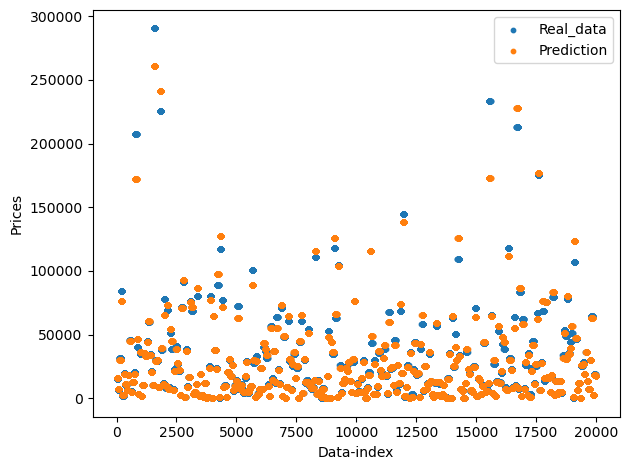

In [85]:
print("Random Forest (left joins including city search index) ")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.2f}")
print(f"MAPE  : {mape:.2f}")

x_axis_indices = np.arange(20000)
plt.scatter(x_axis_indices, Y_test.values[:20000], label='Real_data',s=10)
plt.scatter(x_axis_indices, Y_predict[:20000], label='Prediction',s=10)
plt.xlabel("Data-index")
plt.ylabel("Prices")
plt.tight_layout()
plt.legend()
plt.savefig("predictions_vs_real_left_joins_incl_city_search.png")

- Random Forest (left joins including city search index) RMSE: 4517.16 MAE : 1780.40 R²  : 0.98 MAPE  : 6.84% <br>
  area_new_house_transactions 0.814729 <br>
  price_new_house_transactions 0.085622 <br>
  total_price_per_unit_new_house_transactions 0.043973 <br>
  price_new_house_transactions_nearby_sectors 0.020451 <br>
  num_new_house_transactions 0.016886 <br>
- Random Forest (left joins without city search index) RMSE: 4555.97 MAE : 1226.46 R²  : 0.98 MAPE  : 3.92% <br>
  area_new_house_transactions 0.813007 <br>
  total_price_per_unit_new_house_transactions 0.030403 <br>
  num_new_house_transactions 0.021861 <br>
  price_new_house_transactions_nearby_sectors 0.003410
- Random Forest (inner joins without city search index) - No data in test (after 4.5 year)

In [81]:
# Getting feature importance

feature_names = X_train.columns

importances = loaded_model.feature_importances_

feature_importance_series = pd.Series(importances, index=feature_names)

sorted_importances = feature_importance_series.sort_values(ascending=False)

# Select top 5
top5_features = sorted_importances.head(5)
print(top5_features)

area_new_house_transactions                    0.814729
price_new_house_transactions                   0.085622
total_price_per_unit_new_house_transactions    0.043973
price_new_house_transactions_nearby_sectors    0.020451
num_new_house_transactions                     0.016886
dtype: float64


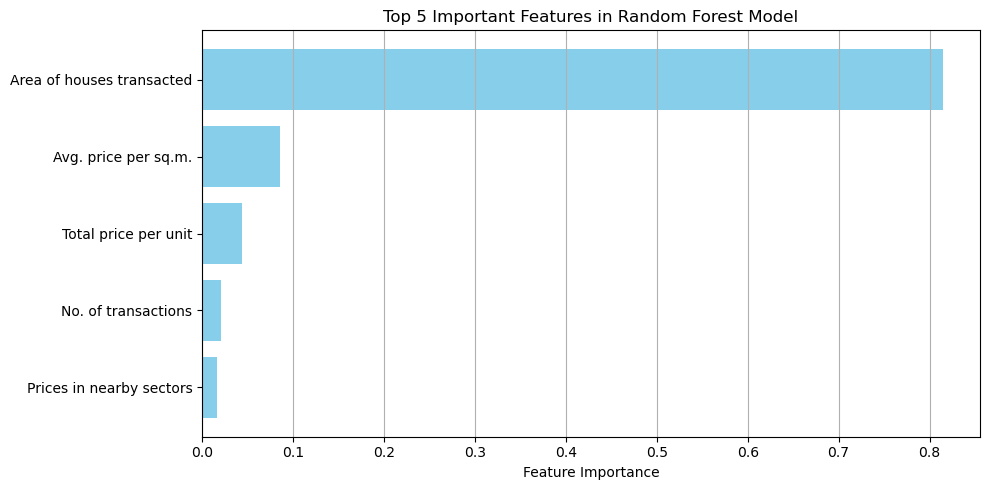

In [82]:
plt.figure(figsize=(10, 5))
#plt.tight_layout()

# Horizontal bar chart for clarity
plt.barh(['Prices in nearby sectors',
       'No. of transactions',
       'Total price per unit',
       'Avg. price per sq.m.', 'Area of houses transacted'], top5_features.values[::-1], color='skyblue')
plt.xlabel("Feature Importance")
plt.title("Top 5 Important Features in Random Forest Model")
plt.grid(axis='x')
plt.tight_layout()
plt.savefig("features_left_joins_incl_city_search.png")
#plt.show()

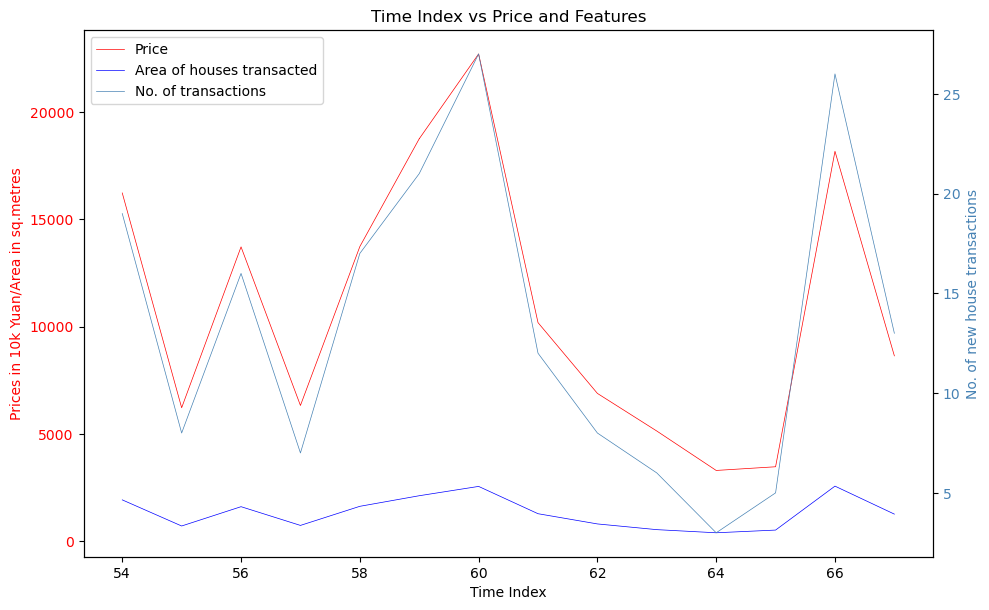

In [83]:

X_test['Prices'] = Y_predict

#plt.figure(figsize=(10, 5))
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(X_test.loc[X_test['sector'] == 1, 'time_index'], X_test.loc[X_test['sector'] == 1, 'Prices'] , label='Price', color='red', linewidth=0.5)
ax1.plot(X_test.loc[X_test['sector'] == 1, 'time_index'], X_test.loc[X_test['sector'] == 1, 'area_new_house_transactions'], label='Area of houses transacted', color='blue', linewidth=0.5)
ax1.set_xlabel('Time Index')
ax1.set_ylabel('Prices in 10k Yuan/Area in sq.metres', color='r')
ax1.tick_params(axis='y', labelcolor='r')

ax2 = ax1.twinx()
ax2.plot(X_test.loc[X_test['sector'] == 1, 'time_index'], X_test.loc[X_test['sector'] == 1, 'num_new_house_transactions'], label='No. of transactions', color='steelblue', linewidth=0.5)
ax2.set_ylabel('No. of new house transactions', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')
#plt.plot(X_test.loc[X_test['sector'] == 1, 'time_index'], X_test.loc[X_test['sector'] == 1, 'num_new_house_transactions'], label='No. of transactions', color='cyan', linewidth=0.5)

#plt.xlabel('Time Index')
#plt.ylabel('Value')
fig.tight_layout()
plt.title('Time Index vs Price and Features')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')
#plt.grid(True)
plt.savefig("features_prices_left_joins_incl_city_search.png")
#plt.show()